# Now Fitting, Quadratic zeeman effect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [ ]:
def add_magnetic_field(filename, timeconst):
    ItB = (0.6*10e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

New file: quadratic_zeeman_data/2p5MH_10s_B.csv
New file: quadratic_zeeman_data/3p6MHz_10s_B.csv
New file: quadratic_zeeman_data/4p45MHz_10s_B.csv
New file: quadratic_zeeman_data/5p5MHz_10s_B.csv
New file: quadratic_zeeman_data/6p7MHz_10s_B.csv
New file: quadratic_zeeman_data/8p65MHz_10s_B.csv
New file: quadratic_zeeman_data/10p8MHz_10s_B.csv


In [3]:
import glob

# Get all CSV files in quadratic_zeeman_data folder, excluding _B files (already processed outputs)
csv_files = sorted([f for f in glob.glob("quadratic_zeeman_data/*.csv") if not f.endswith("_B.csv")])

# Function to convert filename to variable name
def filename_to_varname(filepath):
    # Extract filename without extension
    filename = os.path.basename(filepath).replace(".csv", "")
    # Replace MHz/mHz/kHz with appropriate abbreviations
    varname = filename.replace("MHz", "mhz").replace("mHz", "mhz").replace("kHz", "khz")
    # Replace periods with 'p'
    varname = varname.replace(".", "p").replace("-", "_")
    # Lowercase and add df_ prefix
    varname = f"df_{varname.lower()}"
    return varname

# Create dataframes for all files
dataframes = {}
for filepath in csv_files:
    varname = filename_to_varname(filepath)
    # Determine time constant (using 10s for 10s files, 5s for 5s files)
    timeconst = 1.000000e-02 if "10s" in filepath else 5.000000e-03
    df_temp = add_magnetic_field(filepath, timeconst)
    dataframes[varname] = df_temp
    print(f"{varname}: {filepath}")

# Make dataframes accessible as individual variables
for varname, df_temp in dataframes.items():
    globals()[varname] = df_temp

print(f"\nCreated {len(dataframes)} dataframes")

New file: quadratic_zeeman_data\10p8MHz_10s_B.csv
df_10p8mhz_10s: quadratic_zeeman_data\10p8MHz_10s.csv
New file: quadratic_zeeman_data\13p4MHz_10s_1100_B.csv
df_13p4mhz_10s_1100: quadratic_zeeman_data\13p4MHz_10s_1100.csv
New file: quadratic_zeeman_data\1p5mHz_5s_110_B.csv
df_1p5mhz_5s_110: quadratic_zeeman_data\1p5mHz_5s_110.csv
New file: quadratic_zeeman_data\1p5mHz_5s_172_B.csv
df_1p5mhz_5s_172: quadratic_zeeman_data\1p5mHz_5s_172.csv
New file: quadratic_zeeman_data\2mHz_5s_110_B.csv
df_2mhz_5s_110: quadratic_zeeman_data\2mHz_5s_110.csv
New file: quadratic_zeeman_data\2mHz_5s_75_B.csv
df_2mhz_5s_75: quadratic_zeeman_data\2mHz_5s_75.csv
New file: quadratic_zeeman_data\2p1mHz_5s_164_B.csv
df_2p1mhz_5s_164: quadratic_zeeman_data\2p1mHz_5s_164.csv
New file: quadratic_zeeman_data\2p5MH_10s_B.csv
df_2p5mh_10s: quadratic_zeeman_data\2p5MH_10s.csv
New file: quadratic_zeeman_data\2p5mHz_5s_197_B.csv
df_2p5mhz_5s_197: quadratic_zeeman_data\2p5mHz_5s_197.csv
New file: quadratic_zeeman_data\2p

New file: quadratic_zeeman_data/2p5MH_10s_B.csv
New file: quadratic_zeeman_data/3p6MHz_10s_B.csv
New file: quadratic_zeeman_data/4p45MHz_10s_B.csv
New file: quadratic_zeeman_data/5p5MHz_10s_B.csv
New file: quadratic_zeeman_data/6p7MHz_10s_B.csv
New file: quadratic_zeeman_data/8p65MHz_10s_B.csv
New file: quadratic_zeeman_data/10p8MHz_10s_B.csv


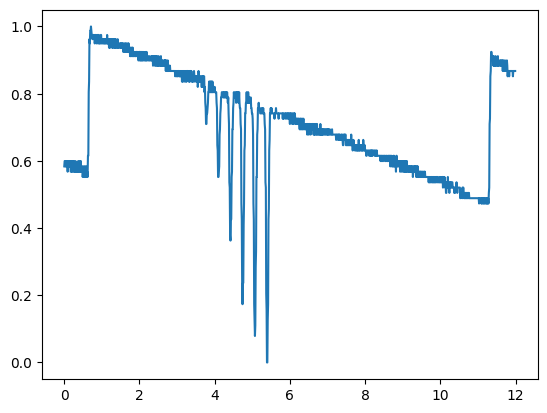

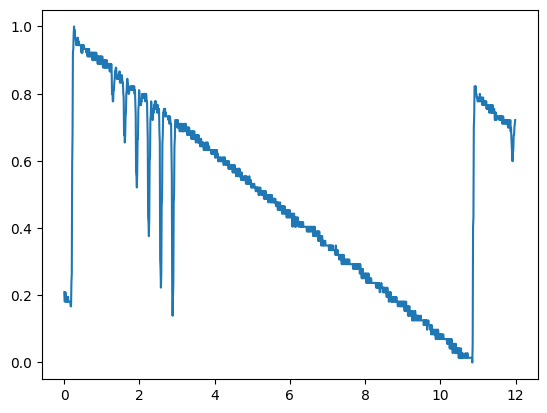

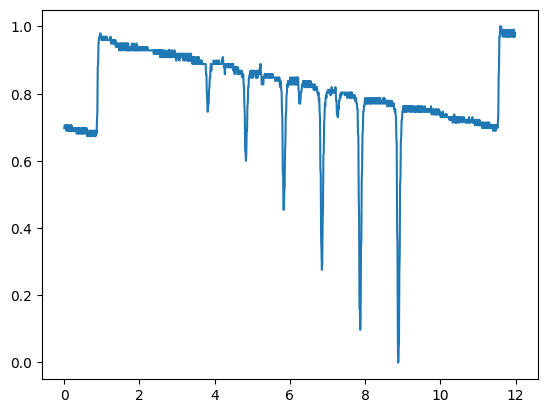

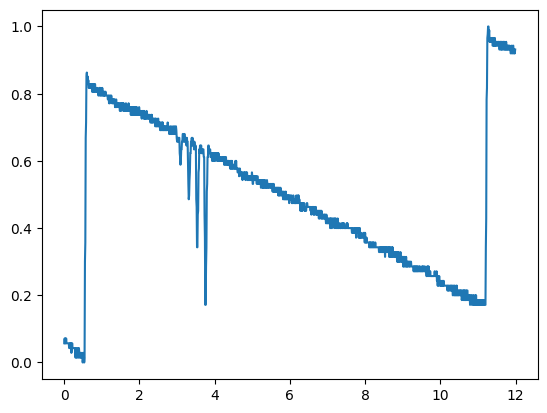

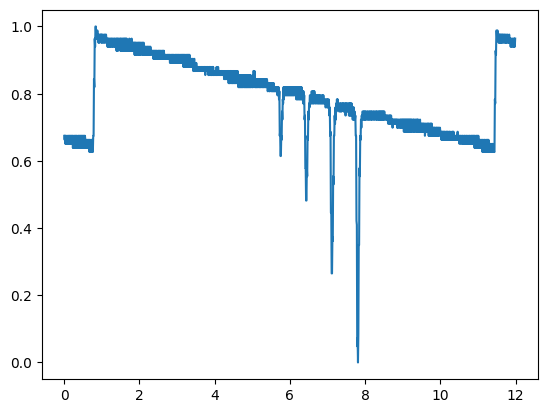

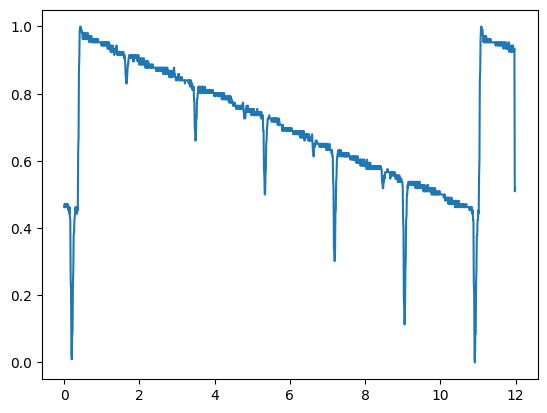

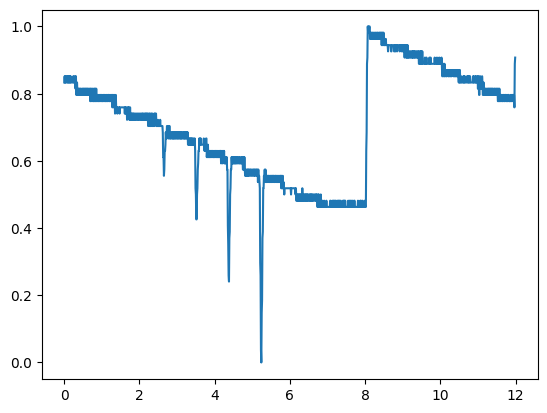

In [10]:
for df_ in df:
    x_data, y_data = df_["time"], df_["CH2norm"]
    plt.plot(x_data, y_data, label='Measured Data', alpha=1)
    plt.show()

In [ ]:
def fit_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    popt, pcov = curve_fit(triple_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1: {popt[2]:.4f} ± {perr[2]:.4f}")
    print(f"Lorentzian peak 2: {popt[5]:.4f} ± {perr[5]:.4f}")
    print(f"Lorentzian peak 3: {popt[8]:.4f} ± {perr[8]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, triple_lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Triple Lorentzian')
    plt.scatter([p0[2], p0[5], p0[8]], [p0[1], p0[4], p0[7]], 
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Triple Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    result_list.append([popt[5], popt[8]])
    return popt, perr